<a href="https://colab.research.google.com/github/HoriaCluj/Duolingo-Datathon/blob/main/Duolingo_Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Duolingo Datathon**

### Team "Zeta" - **Winner "Best Pitch"**

### **Space-Recognition Dataset**
**Variables:**

- `p_recall` = empirical recall probability during that session (Target Variable)
- `timestamp` = absolute time of the recall event (can be converted to a datetime)
- `delta` = time elapsed since the previous exposure of the same lexeme by the same user
- `user_id` = categorical anonymized
- `learning_language` **target** language being learned
- `ui_language` = user (**native**) interface language
- `lexeme_id` = unique identifier for lexical item
- `lexeme_string` = Transformed Form of Word/Base Word
- `history_seen` = Total number of times user has seen this lexeme before this event
- `history_correct` = Number of times previously answered correctly
- `session_seen` = Number of times seen within the current session
- `session_correct` = Correct answers within the current session

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Datathon/DataOne/learning_traces.13m.csv')
df.head()

,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct
0,1.0,1362076081,27649635,u:FO,de,en,76390c1350a8dac31186187e2fe1e178,lernt/lernen<vblex><pri><p3><sg>,6,4,2,2
1,0.5,1362076081,27649635,u:FO,de,en,7dfd7086f3671685e2cf1c1da72796d7,die/die<det><def><f><sg><nom>,4,4,2,1
2,1.0,1362076081,27649635,u:FO,de,en,35a54c25a2cda8127343f6a82e6f6b7d,mann/mann<n><m><sg><nom>,5,4,1,1
3,0.5,1362076081,27649635,u:FO,de,en,0cf63ffe3dda158bc3dbd55682b355ae,frau/frau<n><f><sg><nom>,6,5,2,1
4,1.0,1362076081,27649635,u:FO,de,en,84920990d78044db53c1b012f5bf9ab5,das/das<det><def><nt><sg><nom>,4,4,1,1


In [6]:
df.shape

(12854226, 12)

In [7]:
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
df["date"] = df["datetime"].dt.date

### **Step 1**: Grouping by **`user_id`** and **`date_time`**

In [8]:
dfbt = df.sort_values(["user_id", "datetime"])

### **Step 2:** Computing the session column

In [9]:
dfbt["diff_minutes"] = (
    dfbt.groupby("user_id")["datetime"]
        .diff()
        .dt.total_seconds() / 60)


In [10]:
dfbt[dfbt["diff_minutes"] > 24*60].shape[0]

86901

### **Step 3:** Imposing the 15-Minute Cutoff as a Session

In [11]:
import numpy as np

cutoff = 15

dfbt["sess_int"] = np.where(
    dfbt["diff_minutes"] < cutoff,
    0,
    dfbt["diff_minutes"])

In [12]:
dfbt["new_session"] = (
    dfbt["diff_minutes"].isna() | (dfbt["sess_int"] != 0))

dfbt["session_id"] = (
    dfbt.groupby("user_id")["new_session"]
      .cumsum())
dfbt["session_size"] = (
    dfbt.groupby(["user_id", "session_id"])["session_id"]
      .transform("count"))

In [13]:
dfbt[dfbt['user_id'] == "u:_4-"]

,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct,datetime,date,diff_minutes,sess_int,new_session,session_id,session_size
813567,0.0,1362148959,1358936,u:_4-,es,en,1494e77424cccd4252c3865e5d635be7,cuándo/cuándo<adv><itg>,88,78,1,0,2013-03-01 14:42:39,2013-03-01,NaN,NaN,True,1,39
813568,1.0,1362148959,85659,u:_4-,es,en,6466c217460079d74e1f098116fff664,quiero/querer<vblex><pri><p1><sg>,346,316,2,2,2013-03-01 14:42:39,2013-03-01,0.0,0.0,False,1,39
813569,1.0,1362148959,177889,u:_4-,es,en,eff14ccc2979d8fbd8308ef24983af33,ventana/ventana<n><f><sg>,94,87,1,1,2013-03-01 14:42:39,2013-03-01,0.0,0.0,False,1,39
813570,1.0,1362148959,626609,u:_4-,es,en,28de9c918b4093df7f88896e37213b27,tenemos/tener<vblex><pri><p1><pl>,65,64,1,1,2013-03-01 14:42:39,2013-03-01,0.0,0.0,False,1,39
813571,1.0,1362148959,1799731,u:_4-,es,en,653cd16e8e7ce5bcefebf546a2e0f540,abrir/abrir<vblex><inf>,42,41,1,1,2013-03-01 14:42:39,2013-03-01,0.0,0.0,False,1,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424575,0.0,1363059133,1635972,u:_4-,es,en,836012902ed0ae5d65a6cf6a9d7a863f,llueve/llover<vblex><pri><p3><sg>,45,43,1,0,2013-03-12 03:32:13,2013-03-12,0.0,0.0,False,58,46
12424576,1.0,1363059133,904715,u:_4-,es,en,fa34578c761299f40b07fb6391600388,también/también<adv>,54,47,1,1,2013-03-12 03:32:13,2013-03-12,0.0,0.0,False,58,46
12424577,1.0,1363059133,95221,u:_4-,es,en,3778bcfe5412378caeff2f682510cd92,ese/ese<det><dem><m><sg>,426,384,1,1,2013-03-12 03:32:13,2013-03-12,0.0,0.0,False,58,46
12424578,1.0,1363059133,186196,u:_4-,es,en,4d77de913dc3d65f1c9fac9d1c349684,en/en<pr>,1233,1133,3,3,2013-03-12 03:32:13,2013-03-12,0.0,0.0,False,58,46


### **Step 4:** Aggregating the Dataset for Survival Analysis


In [14]:
session_df = (
    dfbt
    .groupby(["user_id", "session_id"])
    .agg(
        session_size=("session_size", "first"),
        avg_recall=("p_recall", "mean"),
        avg_delta=("delta", "mean"),
        avg_history_seen=("history_seen", "mean"),
        avg_history_correct=("history_correct", "mean"),
        avg_session_seen=("session_seen", "mean"),
        avg_session_correct=("session_correct", "mean"),
        session_start=("datetime", "min"),
        session_end=("datetime", "max"))
    .reset_index())

In [15]:
session_df = session_df.sort_values(['user_id', 'session_start'])

In [16]:
session_df["next_session_start"] = (
    session_df.groupby("user_id")["session_start"]
              .shift(-1))

In [17]:
session_df["time_to_next_session"] = (
    (session_df["next_session_start"] - session_df["session_start"])
        .dt.total_seconds() / 60)

In [18]:
import matplotlib.pyplot as plt

In [19]:
len(session_df[session_df['time_to_next_session'].isna()])

115222

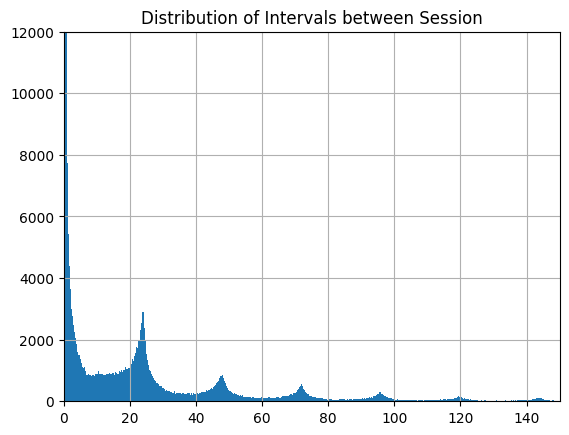

In [20]:
(session_df["time_to_next_session"]/60).dropna().hist(bins=1000)
plt.xlim(0,150)
plt.ylim(0, 12000)
plt.title("Distribution of Intervals between Session")
plt.show()

**Step 5:** Survival Analysis Model

First, we must add a column `event` describing right-censoring, meaning the other never comes back for a session.

In [21]:
session_df["event"] = session_df["time_to_next_session"].notna().astype(int)

In [22]:
session_df["time_to_next_session"].describe()

,time_to_next_session
count,281711.000000
mean,1455.130722
std,2133.914607
min,15.000000
25%,56.650000
50%,705.850000
75%,1661.350000
max,16926.950000


Adding a Categorical Variable describing the `Time of Day` at which the session was performed:

In [23]:
session_df['hour'] = session_df["session_start"].dt.hour

Adding a `Weekend` variable

In [24]:
session_df['weekday'] = session_df["session_start"].dt.dayofweek
session_df["is_weekend"] = session_df["weekday"].isin([5, 6])

In [25]:
session_df = session_df.drop(columns=["next_session_start"])

In [26]:
session_df['interval_hours'] = session_df['time_to_next_session'] / 60

To implement right-censoring:
- If `event` = 1, `interval_hours` = actual time until next session
- If `event` = 0, `interval_hours` = observed follow-up time (censored)

In [27]:
dataset_end = session_df['session_start'].max()
mask_censored_missing = (session_df["event"] == 0) & (session_df["interval_hours"].isna())
session_df.loc[mask_censored_missing, "interval_hours"] = (
    (dataset_end - session_df.loc[mask_censored_missing, "session_start"])
    .dt.total_seconds() / 3600)

In [28]:
session_df['history_ratio'] = session_df['avg_history_correct'] / session_df['avg_history_seen']
session_df['session_ratio'] = session_df['avg_session_correct'] / session_df['avg_session_seen']

Feature-engineering to explain return habits of user, not simply linguistic-performance:

In [29]:
session_df['prev_gap'] = (session_df.groupby("user_id")["interval_hours"].shift(1)).fillna(0)

In [30]:
session_df['session_number'] = (session_df.groupby("user_id")["interval_hours"].cumcount() + 1)

In [31]:
session_df.head()

,user_id,session_id,session_size,avg_recall,avg_delta,avg_history_seen,avg_history_correct,avg_session_seen,avg_session_correct,session_start,...,time_to_next_session,event,hour,weekday,is_weekend,interval_hours,history_ratio,session_ratio,prev_gap,session_number
0,u:--N,1,32,0.809896,1.510561e+07,5.625000,5.093750,1.312500,1.062500,2013-03-02 06:38:33,...,NaN,0,6,5,True,249.606667,0.905556,0.809524,0.0,1
1,u:--U,1,7,0.928571,5.608727e+06,2.857143,2.571429,2.857143,2.714286,2013-03-11 14:05:59,...,NaN,0,14,0,False,26.149444,0.900000,0.950000,0.0,1
2,u:-3I,1,14,0.900000,2.834205e+05,8.428571,7.428571,3.428571,3.000000,2013-03-05 13:40:45,...,NaN,0,13,1,False,170.570000,0.881356,0.875000,0.0,1
3,u:-3n,1,124,0.829973,1.126940e+07,21.854839,19.225806,1.185484,0.991935,2013-03-07 10:34:46,...,NaN,0,10,3,False,125.669722,0.879705,0.836735,0.0,1
4,u:-4V,1,128,0.839844,4.040295e+06,17.148438,16.156250,1.968750,1.804688,2013-03-07 15:21:26,...,45.616667,1,15,3,False,0.760278,0.942141,0.916667,0.0,1


##**Building the `Cox-Model`**

**1) Setting the Features (Predictors)**

In [32]:
import pandas as pd
import numpy as np

df = session_df.copy()

features = ["session_size", "avg_delta", "hour", "history_ratio", "session_ratio",
            "prev_gap", "session_number", "is_weekend"]

df_model = df[["interval_hours", "event", "session_start"] + features].copy()

**2) Splitting into Training & Testing Set**

A time-based split allows us to **predict the future (return) behavior** of an existing user.

In [34]:
df_model = df_model.sort_values("session_start")

cut = df_model["session_start"].quantile(0.8)
train = df_model[df_model["session_start"] <= cut].copy()
test  = df_model[df_model["session_start"] >  cut].copy()

# Removing session_start from model matrix
train = train.drop(columns=["session_start"])
test  = test.drop(columns=["session_start"])

**3) Fitting the Cox Model**

In [35]:
!pip -q install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.9 MB/s eta 0:00:00


In [36]:
from lifelines import CoxPHFitter

In [37]:
cph = CoxPHFitter(penalizer=0.05)
cph.fit(train, duration_col="interval_hours", event_col="event")

<lifelines.CoxPHFitter: fitted with 317546 total observations, 74555 right-censored observations>

In [38]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 317546 total observations, 74555 right-censored observations>
             duration col = 'interval_hours'
                event col = 'event'
                penalizer = 0.05
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 317546
number of events observed = 242991
   partial log-likelihood = -2917657.52
         time fit was run = 2026-03-03 16:09:26 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
session_size    0.00      1.00      0.00            0.00            0.00                1.00                1.00
avg_delta      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
hour            0.00      1.00      0.00            0.00            0.00                1.00                1.00
history_ratio   0.38      1.47      0.03            0.33            0.44                1.39                1.55
session_ratio   0.37      1.44      0.02            0.32            0.41                1.38                1.50
prev_gap       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
session_number  0.05      1.05      0.00            0.05            0.05                1.05                1.05
is_weekend      0.00      1.00      0.00           -0.00            0.01                1.00                1.01

                cmp to      z      p  -log2(p)
covariate                                     
session_size      0.00  25.87 <0.005    487.71
avg_delta         0.00 -35.64 <0.005    921.52
hour              0.00   8.49 <0.005     55.39
history_ratio     0.00  13.93 <0.005    144.10
session_ratio     0.00  17.14 <0.005    216.32
prev_gap          0.00 -11.32 <0.005     96.21
session_number    0.00 193.73 <0.005       inf
is_weekend        0.00   0.91   0.37      1.45
---
Concordance = 0.61
Partial AIC = 5835331.04
log-likelihood ratio test = 30845.57 on 8 df
-log2(p) of ll-ratio test = inf

**4) Evaluating on the Test Set**

In [39]:
train_cindex = cph.score(train, scoring_method="concordance_index")
test_cindex  = cph.score(test, scoring_method="concordance_index")

print(train_cindex, test_cindex)

0.6124896091581571 0.6132611338120404


### Predicting whether a User will return within a certain amount of time **`t`**:

In [40]:
test2 = test[100:120]
test2

,interval_hours,event,session_size,avg_delta,hour,history_ratio,session_ratio,prev_gap,session_number,is_weekend
142541,57.063889,0,6,4.599022e+06,7,0.900000,0.950000,0.000000,1,True
86539,12.415833,1,11,3.477909e+03,7,0.820000,0.928571,0.893056,6,True
182223,0.384444,1,14,5.389500e+03,7,0.854651,0.888889,2.867500,12,True
24557,57.060556,0,29,3.530827e+05,7,0.816568,0.897959,74.181667,3,True
353080,21.735278,1,75,6.292432e+04,7,0.871318,0.892857,50.080556,3,True
224537,57.055833,0,38,1.449811e+04,7,0.860335,0.807018,5.940278,3,True
193,29.315278,1,77,2.980988e+05,7,0.777070,0.690722,30.713056,10,True
20974,1.988889,1,18,6.679617e+04,7,0.791667,0.875000,18.415833,5,True
230462,0.532222,1,7,8.508000e+04,7,0.932203,1.000000,23.633333,8,True
320606,20.088333,1,33,2.571568e+05,7,0.740741,0.794118,48.421667,8,True


Predicting that the second user in the test set returns within 24-Hours:

In [41]:
surv = cph.predict_survival_function(
    test2.iloc[[0]].drop(columns=["interval_hours", "event"]),
    times=[48]
)

prob_return_24h = 1 - surv.loc[48].values[0]
prob_return_24h

np.float64(0.5207109074925347)

**Survival Curve** - Probability that an "Average" Session has **`not returned`** over time (hours):

<Axes: >

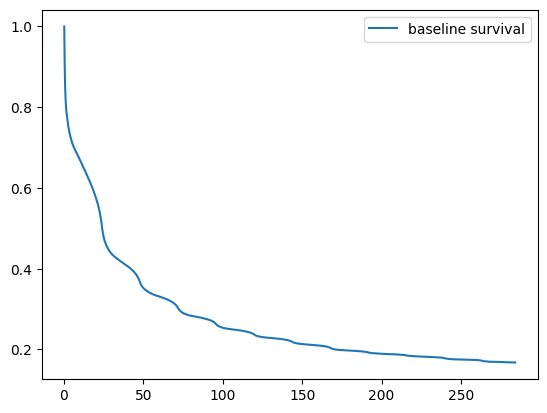

In [42]:
baseline_surv = cph.baseline_survival_
baseline_surv.plot()

**Surival Curve for Two Different Profiles**: High-Previous Gap versus Low-Previous Gap

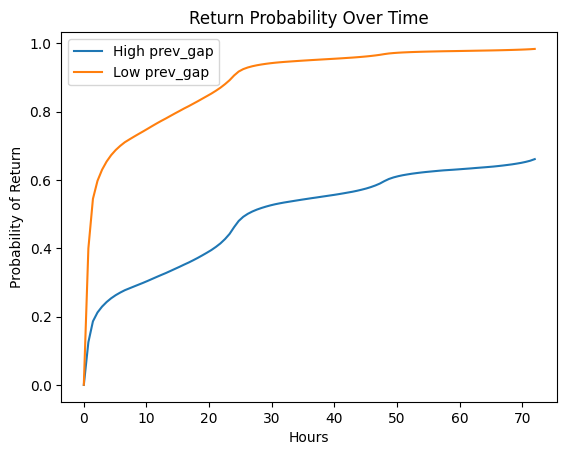

In [43]:
import numpy as np

times = np.linspace(0, 72, 100)

high_gap = test.iloc[[0]].copy()
low_gap = test.iloc[[1]].copy()

surv_high = cph.predict_survival_function(high_gap, times=times)
surv_low  = cph.predict_survival_function(low_gap, times=times)

plt.plot(times, 1 - surv_high.values.flatten(), label="High prev_gap")
plt.plot(times, 1 - surv_low.values.flatten(), label="Low prev_gap")
plt.legend()
plt.title("Return Probability Over Time")
plt.xlabel("Hours")
plt.ylabel("Probability of Return")
plt.show()

**Hazard Ratios** - How much the instantaneous return rate changes when the feature increases by 1 unit.

This plot tells us which `features` accelerate or delay return:

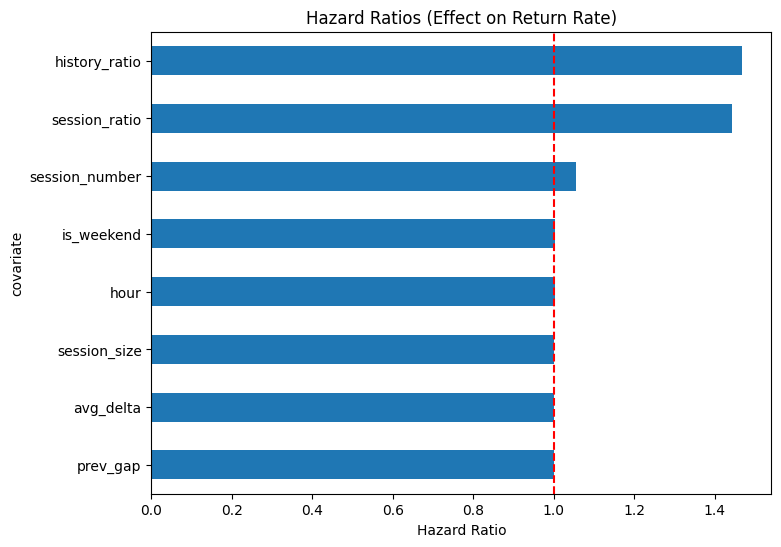

In [44]:
import matplotlib.pyplot as plt

# Extract hazard ratios
hazard_ratios = cph.summary["exp(coef)"]

# Sort for clean visualization
hazard_ratios = hazard_ratios.sort_values()

# Plot
plt.figure(figsize=(8,6))
hazard_ratios.plot(kind="barh")
plt.axvline(x=1, color="red", linestyle="--")  # reference line
plt.title("Hazard Ratios (Effect on Return Rate)")
plt.xlabel("Hazard Ratio")
plt.show()

**Survival Curves:** Short-Burst Learners versus Long-Session Learners

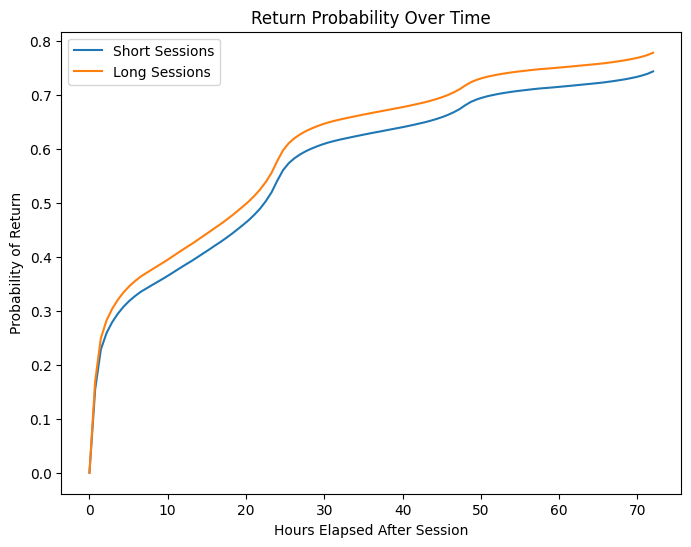

In [45]:
short_threshold = session_df["session_size"].quantile(0.05)
long_threshold  = session_df["session_size"].quantile(0.95)

# Use mean feature values
base_profile = test.drop(columns=["interval_hours", "event"]).mean().to_frame().T

# Create two copies
short_profile = base_profile.copy()
long_profile  = base_profile.copy()

short_profile["session_size"] = short_threshold
long_profile["session_size"]  = long_threshold

import numpy as np

times = np.linspace(0, 72, 100)  # 0–72 hours

surv_short = cph.predict_survival_function(short_profile, times=times)
surv_long  = cph.predict_survival_function(long_profile,  times=times)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(times, 1 - surv_short.values.flatten(), label="Short Sessions")
plt.plot(times, 1 - surv_long.values.flatten(), label="Long Sessions")

plt.xlabel("Hours Elapsed After Session")
plt.ylabel("Probability of Return")
plt.title("Return Probability Over Time")
plt.legend()
plt.show()

### **Testing the Model's Accuracy**

In [46]:
X_test = test.drop(columns=["interval_hours", "event"])

surv_24 = cph.predict_survival_function(X_test, times=[24])

# Probability of returning within 24h
prob_return_24h = 1 - surv_24.loc[24]

pred_24h = (prob_return_24h > 0.5).astype(int)

true_24h = (
    (test["interval_hours"] <= 24) &
    (test["event"] == 1)
).astype(int)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_24h, pred_24h)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error rate:", error_rate)

Accuracy: 0.6164485369141043
Error rate: 0.3835514630858957


Computing the **`AUC`**:

In [47]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(true_24h, prob_return_24h)
print("24h AUC:", auc)

24h AUC: 0.6630959689772646


Compute the **`Confusion Matrix`**:

In [48]:
from sklearn.metrics import confusion_matrix

confusion_matrix(true_24h, pred_24h)

array([[27394, 17365],
       [13084, 21544]])

## **Plotting the Distribution of the 24H Return Probability**

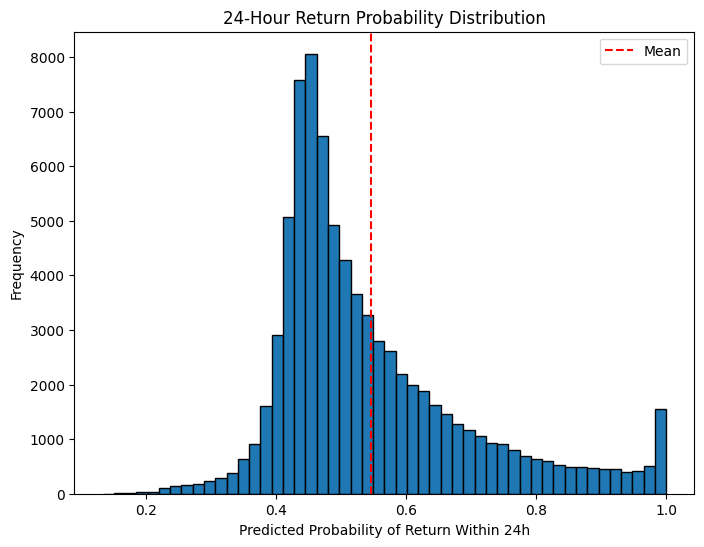

In [49]:
# Separate features
X_test = test.drop(columns=["interval_hours", "event"])

# Predict survival at 24 hours
surv_24 = cph.predict_survival_function(X_test, times=[24])

# Convert survival to return probability
prob_return_24h_all = 1 - surv_24.loc[24]

plt.figure(figsize=(8,6))
plt.hist(prob_return_24h_all, bins=50, edgecolor='black')
plt.axvline(prob_return_24h_all.mean(), color='red', linestyle='--', label='Mean')
plt.xlabel("Predicted Probability of Return Within 24h")
plt.ylabel("Frequency")
plt.title("24-Hour Return Probability Distribution")
plt.legend()
plt.show()

### **Final Graphs to show for the Datathon**

1) Survival Curve for the Average User
2) Survival Curve for Users with Short Previous Gap vs Long Previous Gap
3) Survival Curve for Short-Burst Learners vs Long-Session Learners
4) Distribution of 24-Hour Return Probability
5) Calibration Plot?
6) Brier Score Plot (possibly comparing it to another model)

Potential `3-Dimensional` Graphs:

In [50]:
X_test_with_user_id = test.copy()
X_test_with_user_id['user_id'] = session_df.loc[test.index, 'user_id']

# Predict survival function for 24h, 48h, and 1 week (168h)
surv_24h = cph.predict_survival_function(X_test, times=[24]).loc[24]
surv_48h = cph.predict_survival_function(X_test, times=[48]).loc[48]
surv_72h = cph.predict_survival_function(X_test, times=[72]).loc[72]

# Calculate probability of return (1 - survival probability)
prob_return_24h = 1 - surv_24h
prob_return_48h = 1 - surv_48h
prob_return_72h = 1 - surv_72h

# Create the new dataset
return_predictions_df = pd.DataFrame({
    'user_id': X_test_with_user_id['user_id'],
    'interval_hours': X_test_with_user_id['interval_hours'],
    'previous_gap': X_test_with_user_id['prev_gap'],
    'session_ratio': X_test_with_user_id['session_ratio'],
    'prob_return_24h': prob_return_24h,
    'prob_return_48h': prob_return_48h,
    'prob_return_72h': prob_return_72h
})

display(return_predictions_df.head())

,user_id,interval_hours,previous_gap,session_ratio,prob_return_24h,prob_return_48h,prob_return_72h
40178,u:d_8j,57.225556,13.030556,0.883212,0.462213,0.596968,0.661296
376228,u:iwnb,7.734722,1.549722,0.875000,0.906296,0.968839,0.983954
384135,u:jaT6,7.212778,0.000000,0.893939,0.430940,0.562174,0.626178
65679,u:f-JO,34.383889,91.871389,0.906542,0.473846,0.609676,0.673980
151540,u:h48U,3.773611,3.346389,0.938462,0.504685,0.642730,0.706599


### **History Ratio Graph**

In [52]:
low_history_ratio_percentile = test['history_ratio'].quantile(0.05)
high_history_ratio_percentile = test['history_ratio'].quantile(0.95)

# Create a base profile by taking the mean of all feature columns (excluding target and event)
base_profile_history_ratio = test.drop(columns=["interval_hours", "event"]).mean().to_frame().T

# Create two copies and set the 'history_ratio' to the calculated percentiles
low_history_ratio_profile = base_profile_history_ratio.copy()
low_history_ratio_profile['history_ratio'] = low_history_ratio_percentile

high_history_ratio_profile = base_profile_history_ratio.copy()
high_history_ratio_profile['history_ratio'] = high_history_ratio_percentile

print("Low History_Ratio Profile:")
display(low_history_ratio_profile)

print("\nHigh History_Ratio Profile:")
display(high_history_ratio_profile)

Low History_Ratio Profile:


,session_size,avg_delta,hour,history_ratio,session_ratio,prev_gap,session_number,is_weekend
0,31.700757,1.084466e+06,12.759973,0.761905,0.901355,27.672657,7.796402,0.301006



High History_Ratio Profile:


,session_size,avg_delta,hour,history_ratio,session_ratio,prev_gap,session_number,is_weekend
0,31.700757,1.084466e+06,12.759973,1.0,0.901355,27.672657,7.796402,0.301006


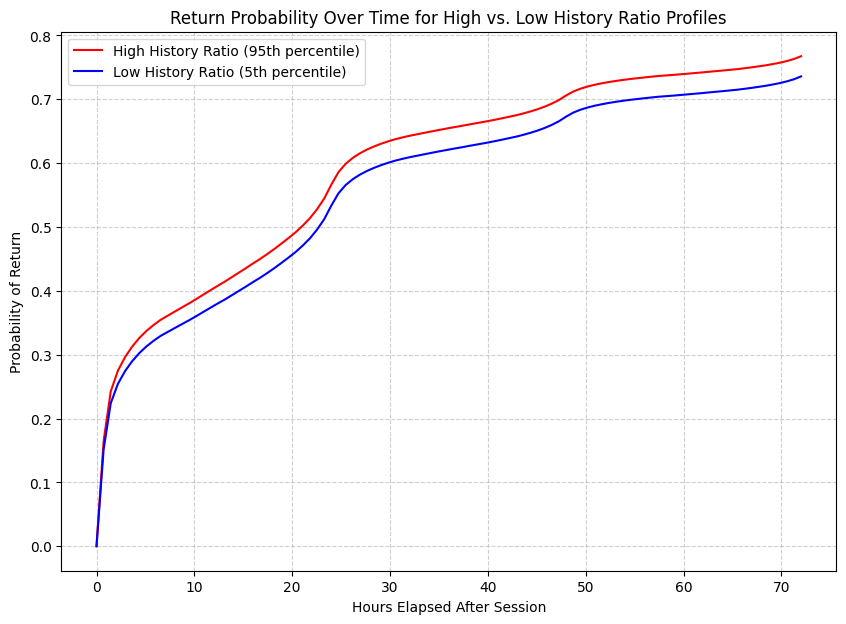

In [53]:
times = np.linspace(0, 72, 100) # 0-72 hours for prediction

# Predict survival functions
surv_high_history_ratio = cph.predict_survival_function(high_history_ratio_profile, times=times)
surv_low_history_ratio = cph.predict_survival_function(low_history_ratio_profile, times=times)

# Convert survival probability to return probability (1 - survival probability)
plt.figure(figsize=(10, 7))
plt.plot(times, 1 - surv_high_history_ratio.values.flatten(), label="High History Ratio (95th percentile)", color='red')
plt.plot(times, 1 - surv_low_history_ratio.values.flatten(), label="Low History Ratio (5th percentile)", color='blue')

plt.title("Return Probability Over Time for High vs. Low History Ratio Profiles")
plt.xlabel("Hours Elapsed After Session")
plt.ylabel("Probability of Return")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Pie Chart Code**

In [54]:
import pandas as pd
import numpy as np

# Assuming session_df exists with columns: user_id, session_number, history_ratio, session_ratio
# Group by user_id, sort sessions by session_number ascending, take last session per user
user_last_sessions = (
    session_df
    .sort_values(['user_id', 'session_number'])
    .groupby('user_id')
    .last()
    .reset_index()
)

# Calculate quantiles for bottom 25% thresholds
low_history_q25 = user_last_sessions['history_ratio'].quantile(0.25)
low_session_q25 = user_last_sessions['session_ratio'].quantile(0.25)

print(f"History_ratio bottom 25% threshold: {low_history_q25:.3f}")
print(f"Session_ratio bottom 25% threshold: {low_session_q25:.3f}")

# Classify users based on last session metrics
def classify_user(row):
    if row['session_number'] <= 3:
        return 'New users'

    is_low_history = row['history_ratio'] <= low_history_q25
    is_low_session = row['session_ratio'] <= low_session_q25

    if not is_low_history and not is_low_session:
        return 'High momentum'  # High history & high session (not low)
    elif not is_low_history and is_low_session:
        return 'Fragile momentum'  # High history, low session
    elif is_low_history and is_low_session:
        return 'At-risk'  # Low history & low session
    else:  # is_low_history and not is_low_session
        return 'Balanced momentum'  # Low history, high session (not in your 4 categories)

user_last_sessions['risk_category'] = user_last_sessions.apply(classify_user, axis=1)

# Summary distribution
print("\nUser Risk Category Distribution:")
print(user_last_sessions['risk_category'].value_counts().sort_index())

# Optional: Merge back to full session_df if needed for session-level analysis
#session_df_with_risk = session_df.merge(
#    user_last_sessions[['user_id', 'risk_category']],
#    on='user_id',
##    how='left'
#)

# View sample
print("\nSample of classified users (last sessions):")
print(user_last_sessions[['user_id', 'session_number', 'history_ratio', 'session_ratio', 'risk_category']].head(10))

History_ratio bottom 25% threshold: 0.846
Session_ratio bottom 25% threshold: 0.852

User Risk Category Distribution:
risk_category
At-risk               2304
Balanced momentum     3406
Fragile momentum      4520
High momentum        22040
New users            82952
Name: count, dtype: int64

Sample of classified users (last sessions):
  user_id  session_number  history_ratio  session_ratio risk_category
0   u:--N               1       0.905556       0.809524     New users
1   u:--U               1       0.900000       0.950000     New users
2   u:-3I               1       0.881356       0.875000     New users
3   u:-3n               1       0.879705       0.836735     New users
4   u:-4V               3       0.918495       0.750000     New users
5   u:-4y               3       0.911392       0.960000     New users
6   u:-5I               2       0.661017       0.818182     New users
7   u:-69               2       0.941176       0.894737     New users
8   u:-7F               1       

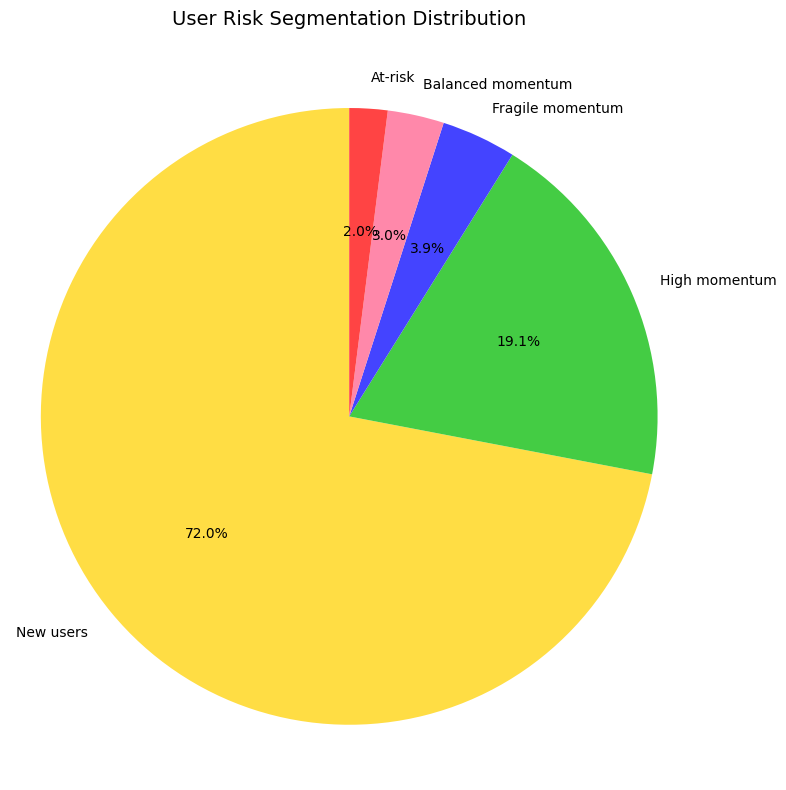

In [55]:
import matplotlib.pyplot as plt

counts = user_last_sessions['risk_category'].value_counts()

colors = {
    'At-risk': '#ff4444',        # Red
    'New users': '#ffdd44',      # Yellow
    'High momentum': '#44cc44',  # Green
    'Fragile momentum': '#4444ff', # Blue
    'Balanced momentum': '#ff88aa' # Pink (if present)
}


# Create pie chart from the risk categories (using user_last_sessions from previous code)
plt.figure(figsize=(8, 8))
user_last_sessions['risk_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors.get(cat, '#cccccc') for cat in counts.index])




plt.title('User Risk Segmentation Distribution', fontsize=14, pad=20)
plt.ylabel('')  # Remove y-label
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.tight_layout()
plt.show()